# Chapter 47 — A Neural Bigram Model

## Learning goals

Earlier chapters built bigram models by counting adjacent tokens.

This chapter learns the same one-token conditional structure with a PyTorch module, cross-entropy, autograd, and an optimizer.

By the end of this chapter, you should be able to:

1. Explain a neural bigram model and contrast it with a counting bigram model.
2. Create character token IDs and adjacent input-target pairs.
3. Use `torch.nn.Embedding` as a direct next-token logit table.
4. Explain the table's row, column, and output shapes.
5. Train the table with cross-entropy loss and AdamW.
6. Compare learned probabilities with empirical counting probabilities.
7. Explain why ambiguous bigrams prevent zero loss.
8. Inspect and plot the learned score table.
9. Generate a deterministic sequence from learned logits.
10. Explain why a neural bigram model remains limited to one token of context.

## The big idea

A counting bigram model stores transition counts:

```text
count[current token, next token]
```

A neural bigram model stores trainable logits:

```text
logit[current token, possible next token]
```

An integer current-token ID selects one row.

That row contains one raw score for every possible next token.

Cross-entropy and gradient-based optimization adjust the table so each row's softmax probabilities fit the observed next-token distribution.

## Terms used in this chapter

- A **bigram model** predicts the next token using only the current token.
- A **vocabulary** is the set of possible tokens.
- A **token ID** is an integer index assigned to one vocabulary token.
- A **bigram pair** contains a current-token input and next-token target.
- A **score table** is a matrix of trainable raw scores.
- A **logit** is a raw class score before softmax.
- An **embedding lookup** selects rows with integer IDs.
- **Cross-entropy** compares a row of logits with the correct next-token class ID.
- An **empirical probability** is a relative frequency computed from counts.
- A **heatmap** maps matrix values to colors.
- **Context length** is the number of previous tokens available to the model.

## Import PyTorch and stay on CPU

Use deterministic initialization and keep every tensor and module on the CPU.

In [1]:
import torch

device = "cpu"
RANDOM_SEED = 47

print("PyTorch version:", torch.__version__)
print("Course device:", device)
print("Random seed:", RANDOM_SEED)

assert device == "cpu"

PyTorch version: 2.2.2
Course device: cpu
Random seed: 47


## Use a tiny visible corpus

The text mostly alternates `a` and `b`, with occasional `b → c → a` transitions.

Its small vocabulary makes every count, score, and probability inspectable.

In [2]:
training_text = "ababababcababababc"

print("Training text:", training_text)
print("Number of characters:", len(training_text))

assert len(training_text) == 18

Training text: ababababcababababc
Number of characters: 18


The final character has no following character inside this corpus.

Every other position supplies one next-token training example.

## Build the character vocabulary

Sort the unique characters so token IDs are deterministic.

Create mappings in both directions for encoding and readable output.

In [3]:
vocabulary = sorted(set(training_text))
vocabulary_size = len(vocabulary)

character_to_id = {character: token_id for token_id, character in enumerate(vocabulary)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}

print("Vocabulary:", vocabulary)
print("Vocabulary size:", vocabulary_size)
print("Character to ID:", character_to_id)
print("ID to character:", id_to_character)

assert vocabulary == ["a", "b", "c"]
assert vocabulary_size == 3
assert set(character_to_id.values()) == set(range(vocabulary_size))

Vocabulary: ['a', 'b', 'c']
Vocabulary size: 3
Character to ID: {'a': 0, 'b': 1, 'c': 2}
ID to character: {0: 'a', 1: 'b', 2: 'c'}


The token IDs are labels rather than numerical measurements.

Their purpose is to select rows and identify target classes.

## Encode the text and form bigram pairs

Each encoded position except the last is an input.

Each encoded position except the first is its corresponding next-token target.

In [4]:
encoded_token_ids = [character_to_id[character] for character in training_text]
current_token_ids_list = encoded_token_ids[:-1]
next_token_ids_list = encoded_token_ids[1:]

print("Encoded text:", encoded_token_ids)
print("Current-token IDs:", current_token_ids_list)
print("Next-token IDs:", next_token_ids_list)
print("Number of examples:", len(current_token_ids_list))

assert len(current_token_ids_list) == len(training_text) - 1
assert len(current_token_ids_list) == len(next_token_ids_list)

Encoded text: [0, 1, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 2]
Current-token IDs: [0, 1, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1]
Next-token IDs: [1, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 2]
Number of examples: 17


The two lists are aligned by position.

For example, the first `a` is paired with the following `b`.

## Inspect every training pair

Decode the aligned IDs to make the next-token task explicit.

In [5]:
print("index | current | next | current ID | next ID")
print("-" * 49)

for pair_index, (current_token_id, next_token_id) in enumerate(
    zip(
        current_token_ids_list,
        next_token_ids_list,
        strict=True,
    )
):
    print(
        f"{pair_index:>5} | "
        f"{id_to_character[current_token_id]:>7} | "
        f"{id_to_character[next_token_id]:>4} | "
        f"{current_token_id:>10} | "
        f"{next_token_id:>7}"
    )

index | current | next | current ID | next ID
-------------------------------------------------
    0 |       a |    b |          0 |       1
    1 |       b |    a |          1 |       0
    2 |       a |    b |          0 |       1
    3 |       b |    a |          1 |       0
    4 |       a |    b |          0 |       1
    5 |       b |    a |          1 |       0
    6 |       a |    b |          0 |       1
    7 |       b |    c |          1 |       2
    8 |       c |    a |          2 |       0
    9 |       a |    b |          0 |       1
   10 |       b |    a |          1 |       0
   11 |       a |    b |          0 |       1
   12 |       b |    a |          1 |       0
   13 |       a |    b |          0 |       1
   14 |       b |    a |          1 |       0
   15 |       a |    b |          0 |       1
   16 |       b |    c |          1 |       2


## Convert token IDs to tensors

Embedding lookup and class-index cross-entropy both expect integer IDs with dtype `torch.long`.

These ID tensors do not require gradients.

In [6]:
current_token_ids = torch.tensor(
    current_token_ids_list,
    dtype=torch.long,
    device=device,
)
next_token_ids = torch.tensor(
    next_token_ids_list,
    dtype=torch.long,
    device=device,
)

print("Current IDs:", current_token_ids)
print("Next IDs:", next_token_ids)
print("Input shape:", current_token_ids.shape)
print("Target shape:", next_token_ids.shape)
print("Input dtype:", current_token_ids.dtype)
print("Target dtype:", next_token_ids.dtype)

assert current_token_ids.shape == torch.Size([17])
assert next_token_ids.shape == torch.Size([17])
assert current_token_ids.dtype == torch.long
assert next_token_ids.dtype == torch.long
assert not current_token_ids.requires_grad
assert not next_token_ids.requires_grad

Current IDs: tensor([0, 1, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1])
Next IDs: tensor([1, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1, 2])
Input shape: torch.Size([17])
Target shape: torch.Size([17])
Input dtype: torch.int64
Target dtype: torch.int64


## Count the observed transitions

Build the counting bigram table first.

Rows represent current tokens, and columns represent next tokens.

In [7]:
bigram_counts = torch.zeros(
    (vocabulary_size, vocabulary_size),
    dtype=torch.float32,
    device=device,
)

for current_token_id, next_token_id in zip(
    current_token_ids_list,
    next_token_ids_list,
    strict=True,
):
    bigram_counts[current_token_id, next_token_id] += 1.0

print("Bigram counts:")
print(bigram_counts)

expected_counts = torch.tensor(
    [
        [0.0, 8.0, 0.0],
        [6.0, 0.0, 2.0],
        [1.0, 0.0, 0.0],
    ],
    dtype=torch.float32,
    device=device,
)
assert torch.equal(bigram_counts, expected_counts)

Bigram counts:
tensor([[0., 8., 0.],
        [6., 0., 2.],
        [1., 0., 0.]])


The counts expose the corpus structure:

- `a` is always followed by `b`.
- `b` is followed by `a` six times and `c` twice.
- The first `c` is followed by `a`.
- The final `c` has no outgoing pair because the corpus ends there.

## Convert counts to empirical probabilities

Normalize each row by the number of observed outgoing transitions.

Every row in this corpus has at least one outgoing transition.

In [8]:
row_totals = bigram_counts.sum(dim=1, keepdim=True)
counting_probability_table = bigram_counts / row_totals

print("Counting probability table:")
print(counting_probability_table)
print("Row sums:", counting_probability_table.sum(dim=1))

expected_counting_probabilities = torch.tensor(
    [
        [0.0, 1.0, 0.0],
        [0.75, 0.0, 0.25],
        [1.0, 0.0, 0.0],
    ],
    dtype=torch.float32,
    device=device,
)
torch.testing.assert_close(
    counting_probability_table,
    expected_counting_probabilities,
)
torch.testing.assert_close(
    counting_probability_table.sum(dim=1),
    torch.ones(vocabulary_size, device=device),
)

Counting probability table:
tensor([[0.0000, 1.0000, 0.0000],
        [0.7500, 0.0000, 0.2500],
        [1.0000, 0.0000, 0.0000]])
Row sums: tensor([1., 1., 1.])


The `b` row is ambiguous because one current token has two observed next tokens.

A model that sees only `b` cannot know which occurrence it is predicting.

## The best bigram loss is not zero

For each observed pair, read the empirical probability assigned to its target and average the negative logarithms.

This is the lowest average cross-entropy available to a bigram distribution that matches the corpus frequencies.

In [9]:
observed_target_probabilities = counting_probability_table[
    current_token_ids,
    next_token_ids,
]
empirical_bigram_loss = -torch.log(observed_target_probabilities).mean()

print("Empirical target probabilities:")
print(observed_target_probabilities)
print("Empirical bigram cross-entropy:", empirical_bigram_loss.item())

assert empirical_bigram_loss.item() > 0.0
torch.testing.assert_close(
    empirical_bigram_loss,
    torch.tensor(0.2646283, device=device),
)

Empirical target probabilities:
tensor([1.0000, 0.7500, 1.0000, 0.7500, 1.0000, 0.7500, 1.0000, 0.2500, 1.0000,
        1.0000, 0.7500, 1.0000, 0.7500, 1.0000, 0.7500, 1.0000, 0.2500])
Empirical bigram cross-entropy: 0.2646282911300659


The unavoidable positive loss comes from the `b` examples.

No single probability row for `b` can assign probability `1` to both `a` and `c`.

## Build a neural bigram module

Use `Embedding(vocabulary_size, vocabulary_size)` as a direct logit lookup table.

This use of `Embedding` does not claim that the rows contain reusable semantic features.

Each row is simply a complete vector of next-token class scores.

In [10]:
class NeuralBigramModel(torch.nn.Module):
    next_token_score_table: torch.nn.Embedding

    def __init__(self, vocabulary_size: int) -> None:
        super().__init__()
        self.next_token_score_table = torch.nn.Embedding(
            num_embeddings=vocabulary_size,
            embedding_dim=vocabulary_size,
        )

    def forward(
        self,
        input_token_ids: torch.Tensor,
    ) -> torch.Tensor:
        next_token_logits = self.next_token_score_table(input_token_ids)
        assert isinstance(next_token_logits, torch.Tensor)
        return next_token_logits


torch.manual_seed(RANDOM_SEED)
model = NeuralBigramModel(vocabulary_size).to(device)

print(model)
print("Score-table shape:", model.next_token_score_table.weight.shape)
print("Parameter count:", sum(p.numel() for p in model.parameters()))

assert model.next_token_score_table.weight.shape == torch.Size([3, 3])
assert sum(parameter.numel() for parameter in model.parameters()) == 9
assert model.next_token_score_table.weight.device.type == "cpu"

NeuralBigramModel(
  (next_token_score_table): Embedding(3, 3)
)
Score-table shape: torch.Size([3, 3])
Parameter count: 9


The table contains `vocabulary_size²` scalar parameters.

Rows correspond to input IDs, while columns correspond to candidate next-token IDs.

## Look up one row of logits

Pass the ID for `a` as a one-element batch.

The output has one row and one column per possible next token.

In [11]:
a_token_id = torch.tensor(
    [character_to_id["a"]],
    dtype=torch.long,
    device=device,
)
a_next_token_logits = model(a_token_id)

print("Current token:", id_to_character[int(a_token_id.item())])
print("Next-token logits:", a_next_token_logits)
print("Output shape:", a_next_token_logits.shape)

assert a_next_token_logits.shape == torch.Size([1, vocabulary_size])

Current token: a
Next-token logits: tensor([[-1.4624,  0.7523, -1.7173]], grad_fn=<EmbeddingBackward0>)
Output shape: torch.Size([1, 3])


The values are arbitrary initial logits.

They can be negative or greater than one and do not need to sum to anything.

## A lookup equals one-hot matrix multiplication

Selecting rows from this table is mathematically equivalent to multiplying one-hot input rows by the table.

The embedding lookup avoids materializing those mostly-zero one-hot vectors in model code.

In [12]:
initial_batch_logits = model(current_token_ids)
one_hot_inputs = torch.nn.functional.one_hot(
    current_token_ids,
    num_classes=vocabulary_size,
).to(torch.float32)
explicit_batch_logits = one_hot_inputs @ model.next_token_score_table.weight

print("Lookup-logit shape:", initial_batch_logits.shape)
print("One-hot shape:", one_hot_inputs.shape)
print("Explicit-logit shape:", explicit_batch_logits.shape)

torch.testing.assert_close(
    initial_batch_logits,
    explicit_batch_logits,
)
assert initial_batch_logits.shape == torch.Size(
    [len(current_token_ids), vocabulary_size]
)

Lookup-logit shape: torch.Size([17, 3])
One-hot shape: torch.Size([17, 3])
Explicit-logit shape: torch.Size([17, 3])


This model is a table lookup written in neural-network form.

Its output shape is `[number_of_examples, number_of_classes]`, exactly what multiclass cross-entropy expects.

## Compute cross-entropy from raw logits

Targets are integer next-token class IDs.

Do not apply softmax before `CrossEntropyLoss`; the loss combines the required normalization and negative log calculation stably.

In [13]:
loss_function = torch.nn.CrossEntropyLoss()
initial_loss = loss_function(
    initial_batch_logits,
    next_token_ids,
)

print("Logit shape:", initial_batch_logits.shape)
print("Target shape:", next_token_ids.shape)
print("Initial loss:", initial_loss.item())

assert initial_loss.shape == torch.Size([])
assert initial_loss.item() > empirical_bigram_loss.item()

Logit shape: torch.Size([17, 3])
Target shape: torch.Size([17])
Initial loss: 0.7159619331359863


The randomly initialized table performs worse than the empirical bigram distribution.

Training should move its row probabilities toward the counting probabilities.

## Train the neural bigram model

Use AdamW with weight decay disabled so the objective is not mixed with parameter shrinkage.

The complete tiny dataset forms one full batch at every step.

In [14]:
torch.manual_seed(RANDOM_SEED)
model = NeuralBigramModel(vocabulary_size).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.1,
    weight_decay=0.0,
)
number_of_steps = 300
training_history: list[dict[str, float]] = []

for step in range(number_of_steps):
    next_token_logits = model(current_token_ids)
    loss = loss_function(next_token_logits, next_token_ids)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    training_history.append(
        {
            "step": float(step),
            "loss": loss.item(),
        }
    )

with torch.no_grad():
    final_logits = model(current_token_ids)
    final_loss = loss_function(final_logits, next_token_ids)

print("Initial training loss:", training_history[0]["loss"])
print("Final recorded loss:", training_history[-1]["loss"])
print("Final recomputed loss:", final_loss.item())
print("Empirical bigram loss:", empirical_bigram_loss.item())

assert training_history[-1]["loss"] < training_history[0]["loss"]
assert abs(final_loss.item() - empirical_bigram_loss.item()) < 0.002

Initial training loss: 0.7159619331359863
Final recorded loss: 0.26544320583343506
Final recomputed loss: 0.265439510345459
Empirical bigram loss: 0.2646282911300659


The learned loss approaches the empirical bigram loss rather than zero.

The remaining small difference comes from finite optimization and softmax probabilities that remain positive for unseen transitions.

## Plot the training loss

Show both the neural loss and the empirical bigram reference.

The horizontal line makes convergence toward the one-token optimum visible.

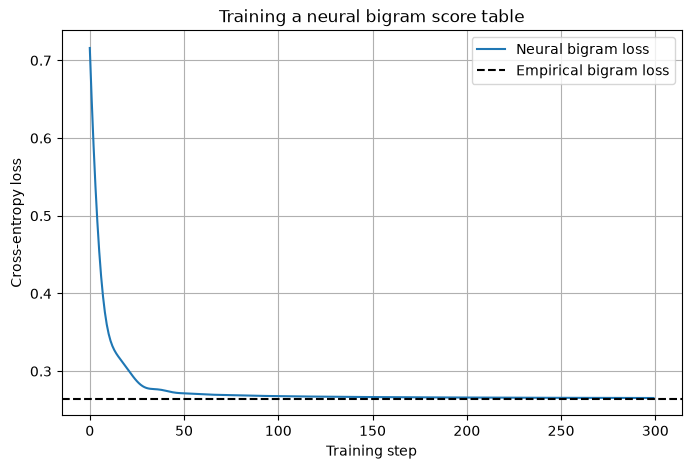

In [15]:
import matplotlib.pyplot as plt

training_steps = [int(row["step"]) for row in training_history]
training_losses = [row["loss"] for row in training_history]

plt.figure(figsize=(8, 5))
plt.plot(training_steps, training_losses, label="Neural bigram loss")
plt.axhline(
    empirical_bigram_loss.item(),
    color="black",
    linestyle="--",
    label="Empirical bigram loss",
)
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Training a neural bigram score table")
plt.legend()
plt.grid(True)
plt.show()

The curve flattens near the empirical reference.

More optimization cannot resolve information that the one-token input does not contain.

## Inspect learned logits and probabilities

Detach the trained parameter for reporting.

Softmax each row to obtain a next-token probability distribution.

In [16]:
learned_score_table = model.next_token_score_table.weight.detach().clone()
learned_probability_table = torch.softmax(
    learned_score_table,
    dim=1,
)

print("Learned logits:")
print(learned_score_table)
print("Learned probabilities:")
print(learned_probability_table)
print("Probability row sums:", learned_probability_table.sum(dim=1))

torch.testing.assert_close(
    learned_probability_table.sum(dim=1),
    torch.ones(vocabulary_size, device=device),
)
torch.testing.assert_close(
    learned_probability_table,
    counting_probability_table,
    atol=0.002,
    rtol=0.0,
)

Learned logits:
tensor([[-4.6160,  3.9059, -4.8709],
        [ 2.8707, -3.6250,  1.7716],
        [ 3.8597, -3.2131, -2.9875]])
Learned probabilities:
tensor([[1.9898e-04, 9.9965e-01, 1.5422e-04],
        [7.4926e-01, 1.1312e-03, 2.4961e-01],
        [9.9809e-01, 8.4627e-04, 1.0605e-03]])
Probability row sums: tensor([1.0000, 1.0000, 1.0000])


The learned and counting probabilities are close.

They are not exactly identical because finite logits cannot produce an exact probability of zero or one.

## Print learned and counting probabilities together

Label every row and column so the comparison is readable without remembering token IDs.

In [17]:
print("current → next | learned probability | counting probability")
print("-" * 62)

for current_token_id, current_token in enumerate(vocabulary):
    for next_token_id, next_token in enumerate(vocabulary):
        learned_probability = learned_probability_table[
            current_token_id,
            next_token_id,
        ].item()
        counting_probability = counting_probability_table[
            current_token_id,
            next_token_id,
        ].item()

        print(
            f"{current_token} → {next_token:>4} | "
            f"{learned_probability:>19.6f} | "
            f"{counting_probability:>20.6f}"
        )

current → next | learned probability | counting probability
--------------------------------------------------------------
a →    a |            0.000199 |             0.000000
a →    b |            0.999647 |             1.000000
a →    c |            0.000154 |             0.000000
b →    a |            0.749258 |             0.750000
b →    b |            0.001131 |             0.000000
b →    c |            0.249611 |             0.250000
c →    a |            0.998093 |             1.000000
c →    b |            0.000846 |             0.000000
c →    c |            0.001060 |             0.000000


The highest learned transition after `b` is `a`, while `c` retains substantial probability because it appears twice.

The unseen `b → b` transition receives a small positive probability rather than an exact zero.

## Plot the learned score table

The required heatmap shows raw learned logits.

Raw logits are only meaningful relative to other logits in the same row because adding one constant to every entry in a row leaves its softmax probabilities unchanged.

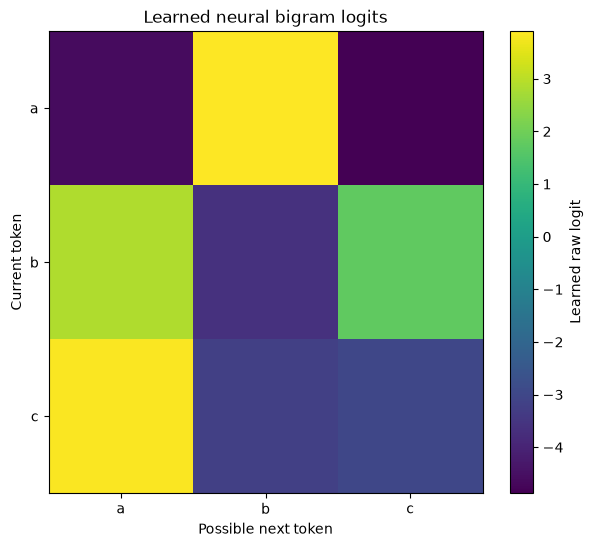

In [18]:
plt.figure(figsize=(7, 6))
plt.imshow(learned_score_table.cpu().numpy(), aspect="auto")
plt.colorbar(label="Learned raw logit")
plt.xticks(
    ticks=list(range(vocabulary_size)),
    labels=vocabulary,
)
plt.yticks(
    ticks=list(range(vocabulary_size)),
    labels=vocabulary,
)
plt.xlabel("Possible next token")
plt.ylabel("Current token")
plt.title("Learned neural bigram logits")
plt.show()

Rows are current tokens, and columns are candidate next tokens.

Color reveals which candidate is favored within each row, but absolute colors should not be interpreted as probabilities.

## Evaluate most-likely predictions

Argmax chooses the highest-logit next token for each example.

The ambiguous `b → c` examples remain errors because `b → a` is more common.

In [19]:
predicted_next_token_ids = final_logits.argmax(dim=1)
prediction_accuracy = (
    (predicted_next_token_ids == next_token_ids).to(torch.float32).mean()
)

print("Prediction accuracy:", prediction_accuracy.item())

for current_token in vocabulary:
    current_token_id = character_to_id[current_token]
    predicted_token_id = int(learned_score_table[current_token_id].argmax().item())
    print(
        "current:",
        current_token,
        "most likely next:",
        id_to_character[predicted_token_id],
    )

torch.testing.assert_close(
    prediction_accuracy,
    torch.tensor(15.0 / 17.0, device=device),
)

Prediction accuracy: 0.8823529481887817
current: a most likely next: b
current: b most likely next: a
current: c most likely next: a


The maximum possible argmax accuracy for these one-token inputs is `15 / 17`.

The two `b → c` targets conflict with the more frequent `b → a` target for the same input.

## Generate with argmax

Repeatedly feed the chosen token back as the next current token.

This deterministic strategy exposes the model's tendency to enter a simple high-probability cycle.

In [20]:
def generate_with_argmax(
    model: NeuralBigramModel,
    starting_token_id: int,
    number_of_new_tokens: int,
) -> list[int]:
    generated_token_ids = [starting_token_id]
    current_token_id = starting_token_id

    for _ in range(number_of_new_tokens):
        current_id_tensor = torch.tensor(
            [current_token_id],
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            next_token_logits = model(current_id_tensor)
            current_token_id = int(next_token_logits.argmax(dim=1).item())

        generated_token_ids.append(current_token_id)

    return generated_token_ids


generated_token_ids = generate_with_argmax(
    model=model,
    starting_token_id=character_to_id["a"],
    number_of_new_tokens=20,
)
generated_text = "".join(id_to_character[token_id] for token_id in generated_token_ids)

print("Generated text:", generated_text)

assert generated_text == "ababababababababababa"

Generated text: ababababababababababa


Argmax loops between `a` and `b` because those are the most likely transitions.

Sampling could occasionally choose `c`, but it would not give the model any additional context or understanding.

## Neural and counting bigrams

Both approaches represent one conditional distribution row per current token.

| Counting bigram | Neural bigram |
|---|---|
| Accumulates transition counts directly | Starts with trainable logits |
| Normalizes rows into probabilities | Applies softmax to rows |
| Fits frequencies without gradient descent | Fits targets with cross-entropy and an optimizer |
| Produces exact zeros for unseen transitions | Produces positive softmax probabilities for finite logits |
| Uses one current token | Uses one current token |

The neural form is valuable because its loss, gradients, modules, and optimizers extend to richer architectures later.

## Parameter growth

The direct score table contains `vocabulary_size²` parameters.

A three-character vocabulary needs only nine.

A vocabulary of 50,000 tokens would require 2.5 billion logits before storing optimizer state or gradients.

Real language models use lower-dimensional embeddings and shared transformations rather than this full direct bigram table as their complete architecture.

In [21]:
large_vocabulary_size = 50_000
large_bigram_parameter_count = large_vocabulary_size * large_vocabulary_size

print("Vocabulary size:", large_vocabulary_size)
print("Direct bigram parameters:", large_bigram_parameter_count)

assert large_bigram_parameter_count == 2_500_000_000

Vocabulary size: 50000
Direct bigram parameters: 2500000000


## Why neural does not automatically mean powerful

This model has trainable parameters, a loss, gradients, and an optimizer.

Its architecture still receives only one current token ID.

It cannot distinguish two histories that end in the same token.

It therefore cannot represent dependencies such as:

- Matching distant parentheses.
- Remembering a name from earlier text.
- Tracking whether a quote was opened.
- Using a multi-token phrase as context.

Model capability depends on available information and computation, not on the label “neural” by itself.

## What not to do

- Do not confuse this score lookup with a transformer.
- Do not describe the table rows as semantic embeddings in this model.
- Do not apply softmax before `CrossEntropyLoss`.
- Do not make input or target token IDs floating point.
- Do not compare raw logits across rows as if their absolute offsets were meaningful.
- Do not expect zero loss when one current token has multiple observed targets.
- Do not expect the model to use tokens it never receives as input context.
- Do not assume neural automatically means expressive.

## Gotchas

- The embedding layer maps each input ID directly to vocabulary-sized logits.
- Rows represent current tokens, and columns represent candidate next tokens.
- Token IDs perform lookup and identify classes but do not receive gradients.
- Finite softmax logits assign positive probability to every class.
- The empirical bigram optimum can have positive loss when transitions are ambiguous.
- Argmax generation can collapse into a simple cycle.
- The direct table grows quadratically with vocabulary size.

## Takeaways

A neural bigram model learns one row of next-token logits for each current token.

Adjacent token IDs provide input-target training pairs.

`Embedding(vocabulary_size, vocabulary_size)` performs the direct row lookup, and cross-entropy trains its floating-point table.

The learned probabilities closely match counting probabilities on the same corpus.

The nonzero best loss and imperfect argmax accuracy come from ambiguity that one token of context cannot resolve.

The model is neural in its training machinery, but it remains a bigram model with a context length of one.

## What comes next

The next chapter will give the model several previous tokens instead of one.

That change requires representing token sequences and combining information across a context window, moving beyond a direct bigram lookup toward richer language-model architectures.